Seleção de colunas e PCA

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display
from sklearn.model_selection import TimeSeriesSplit
import time
import psutil
import os
tscv = TimeSeriesSplit(n_splits=5)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df = pd.read_csv("./raw/dataset_merged_binary.csv", parse_dates=["date"])

cols = ["date", "credit_spread", "industrial_production", "price_index",
        "real_interest", "volatility_index", "yield_curve_slope", "target_12m"]

df = df[cols].dropna().reset_index(drop=True)

features = ["credit_spread", "industrial_production", "price_index",
            "real_interest", "volatility_index", "yield_curve_slope"]

X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["pca_1", "pca_2","pca_3"])
df_pca = pd.concat(
    [df_pca, df[["date", "target_12m"]].reset_index(drop=True)],
    axis=1
)

variancia_explicada = pca.explained_variance_ratio_
variacia_total = variancia_explicada.sum()

print(f"Variancia explicada pela PC1: {variancia_explicada[0]:.2%}")
print(f"Variancia explicada pela PC2: {variancia_explicada[1]:.2%}")
print(f"Variancia explicada pela PC3: {variancia_explicada[2]:.2%}")

print(f"Variância total explicada pelos três componentes: {variacia_total:.2%}")

Variancia explicada pela PC1: 44.70%
Variancia explicada pela PC2: 30.59%
Variancia explicada pela PC3: 15.77%
Variância total explicada pelos três componentes: 91.06%


Matriz de Correlação

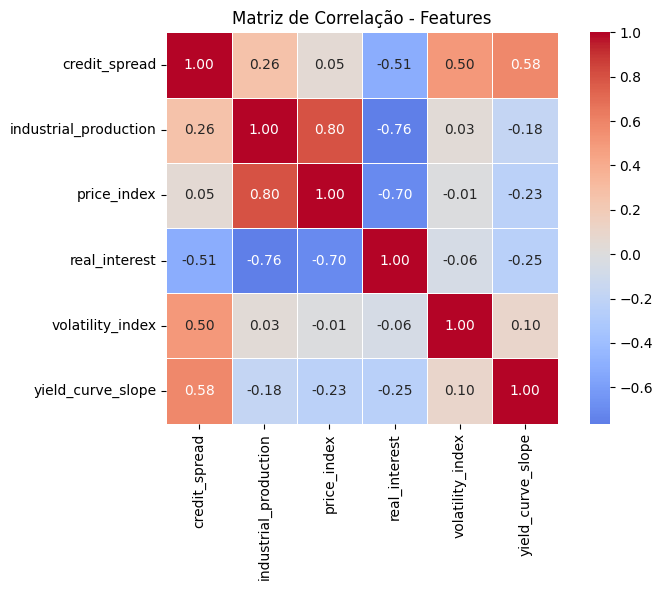

Matriz de Correlação:
                       credit_spread  industrial_production  price_index  real_interest  volatility_index  yield_curve_slope
credit_spread               1.000000               0.261203     0.050529      -0.514573          0.497201           0.578270
industrial_production       0.261203               1.000000     0.796499      -0.763384          0.031189          -0.176839
price_index                 0.050529               0.796499     1.000000      -0.701841         -0.009535          -0.227614
real_interest              -0.514573              -0.763384    -0.701841       1.000000         -0.060111          -0.246184
volatility_index            0.497201               0.031189    -0.009535      -0.060111          1.000000           0.098193
yield_curve_slope           0.578270              -0.176839    -0.227614      -0.246184          0.098193           1.000000


In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matriz de Correlação - Features")
plt.tight_layout()
plt.show()

print("Matriz de Correlação:")
print(corr.to_string())

Divisão entre treino e teste

In [90]:
from sklearn.model_selection import train_test_split

df = df.sort_values("date").reset_index(drop=True)
df_pca = df_pca.sort_values("date").reset_index(drop=True)

X_no_pca = df[features]
X_pca_features = df_pca[["pca_1", "pca_2", "pca_3"]]
y = df["target_12m"]

X_train_no_pca, X_test_no_pca, y_train_no_pca, y_test_no_pca = train_test_split(
    X_no_pca,
    y,
    test_size=0.3,
    random_state=42,
    shuffle=False,
)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_features,
    y,
    test_size=0.3,
    random_state=42,
    shuffle=False,
)

Função base de treino, teste e plot dos modelos

In [91]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

import matplotlib.pyplot as plt
import pandas as pd

LABELS = ["Normal", "Crise"]
ALL_CLASSES = [0, 1]

resultados = []

def avaliar_modelo(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    nome_modelo="Modelo",
    tempo_treino=None,
    tempo_predicao=None,
    memoria_mb=None
):

    print(f"\n===== {nome_modelo} =====")

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("\n--- TREINO ---")
    print(
        classification_report(
            y_train,
            y_pred_train,
            labels=ALL_CLASSES,
            target_names=LABELS,
            zero_division=0
        )
    )

    print("\n--- TESTE ---")
    print(
        classification_report(
            y_test,
            y_pred_test,
            labels=ALL_CLASSES,
            target_names=LABELS,
            zero_division=0
        )
    )

    # ===== INFORMAÇÕES COMPUTACIONAIS =====

    if tempo_treino is not None:
        print(f"\nTempo de treino: {tempo_treino:.4f} s")

    if tempo_predicao is not None:
        print(f"Tempo de predição: {tempo_predicao * 1000:.4f} ms")

    if memoria_mb is not None:
        print(f"Memória utilizada: {memoria_mb:.2f} MB")

    # ===== ACUMULA RESULTADOS =====
    resultados.append({
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(
            y_test,
            y_pred_test,
            average="macro",
            labels=ALL_CLASSES,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred_test,
            average="macro",
            labels=ALL_CLASSES,
            zero_division=0
        ),
        "f1_macro": f1_score(
            y_test,
            y_pred_test,
            average="macro",
            labels=ALL_CLASSES,
            zero_division=0
        ),
        "tempo_treino_s": tempo_treino
    })

    # ===== MATRIZES DE CONFUSÃO =====

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    cm_train = confusion_matrix(
        y_train,
        y_pred_train,
        labels=ALL_CLASSES
    )

    ConfusionMatrixDisplay(
        cm_train,
        display_labels=LABELS
    ).plot(
        ax=axes[0],
        xticks_rotation=45
    )

    axes[0].set_title(
        f"{nome_modelo} - Matriz de Confusão (Treino)"
    )

    cm_test = confusion_matrix(
        y_test,
        y_pred_test,
        labels=ALL_CLASSES
    )

    ConfusionMatrixDisplay(
        cm_test,
        display_labels=LABELS
    ).plot(
        ax=axes[1],
        xticks_rotation=45
    )

    axes[1].set_title(
        f"{nome_modelo} - Matriz de Confusão (Teste)"
    )

    plt.tight_layout()
    plt.show()

Árvore de Decisão

Melhores parâmetros (sem PCA):
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

===== Decision Tree (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.93      0.93      0.93       147
       Crise       0.94      0.93      0.93       157

    accuracy                           0.93       304
   macro avg       0.93      0.93      0.93       304
weighted avg       0.93      0.93      0.93       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.68      0.92      0.78        91
       Crise       0.00      0.00      0.00        40

    accuracy                           0.64       131
   macro avg       0.34      0.46      0.39       131
weighted avg       0.47      0.64      0.54       131


Tempo de treino: 0.4982 s
Tempo de predição: 0.0000 ms
Memória utilizada: 265.43 MB


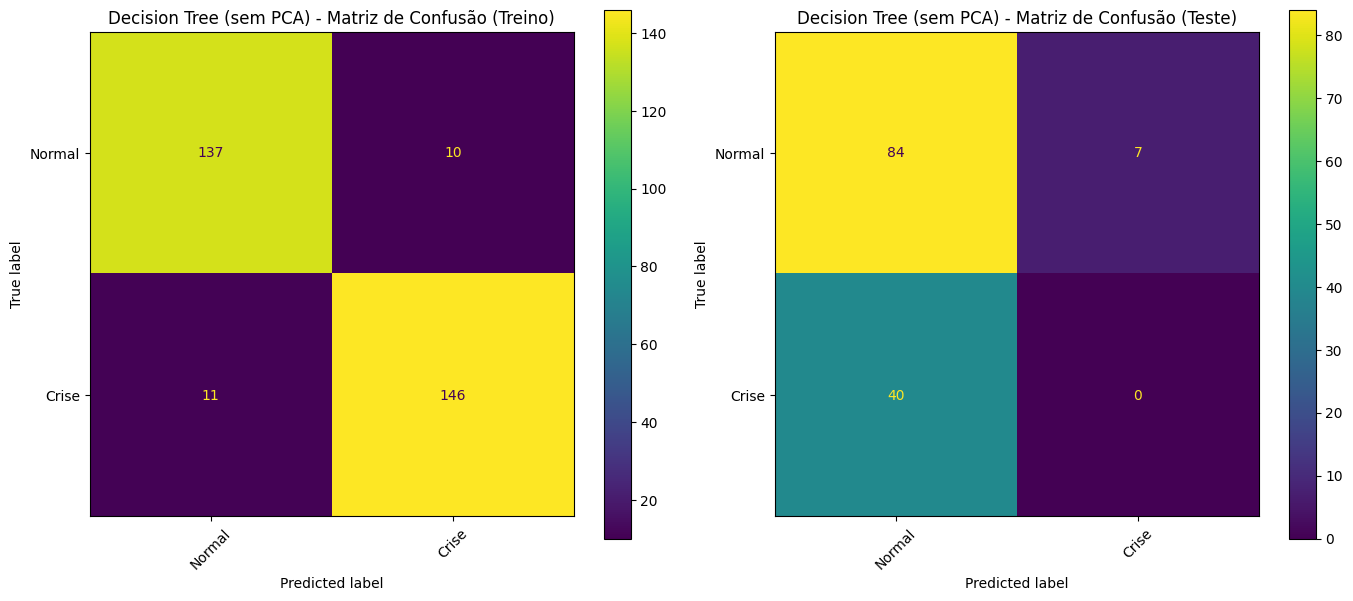

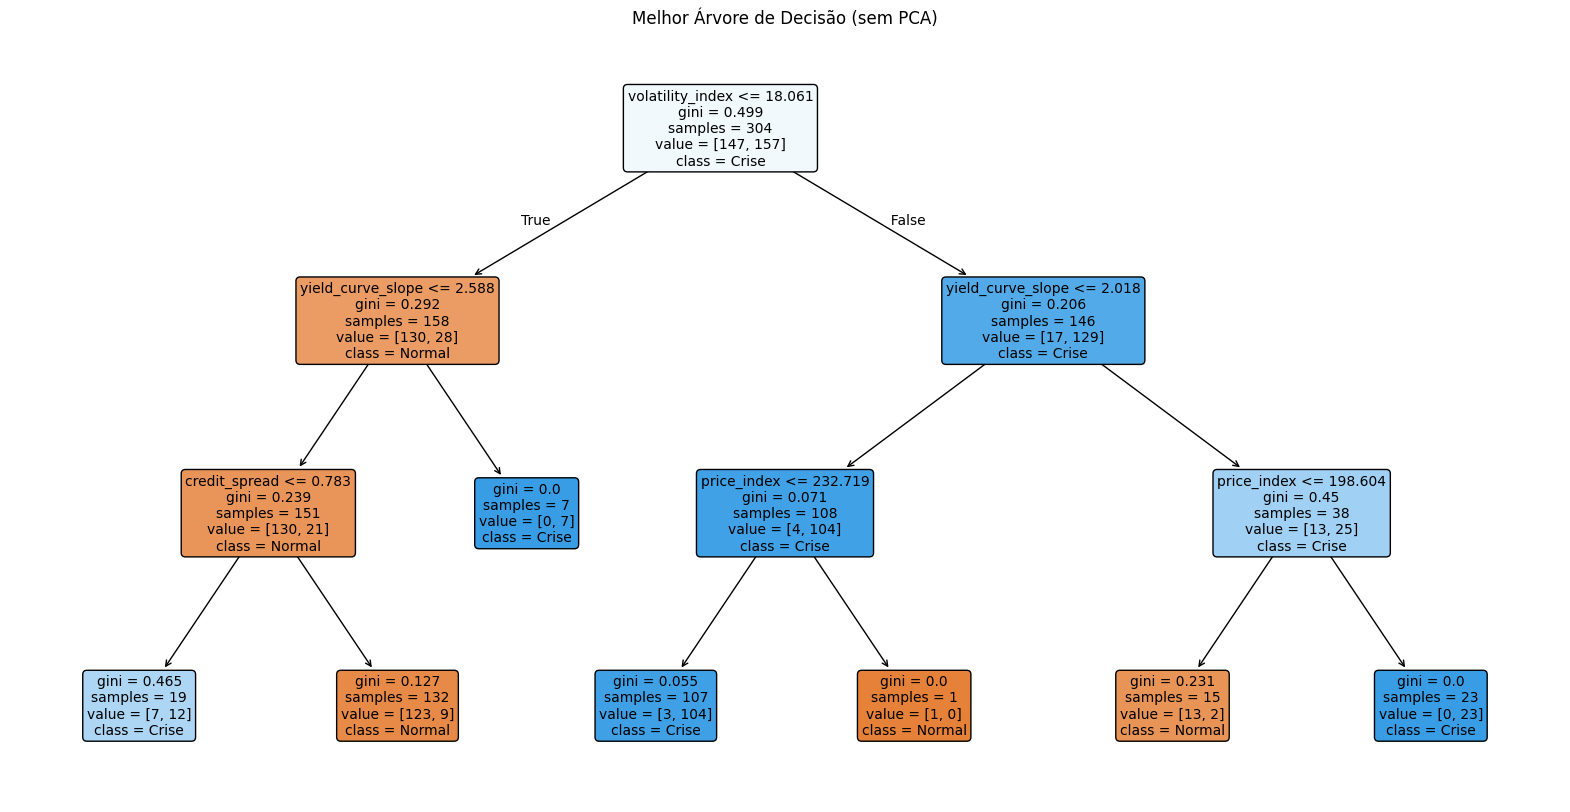

Melhores parâmetros (PCA):
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

===== Decision Tree (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.96       147
       Crise       0.97      0.94      0.96       157

    accuracy                           0.96       304
   macro avg       0.96      0.96      0.96       304
weighted avg       0.96      0.96      0.96       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.73      0.40      0.51        91
       Crise       0.33      0.68      0.44        40

    accuracy                           0.48       131
   macro avg       0.53      0.54      0.48       131
weighted avg       0.61      0.48      0.49       131


Tempo de treino: 0.5205 s
Tempo de predição: 1.6179 ms
Memória utilizada: 275.73 MB


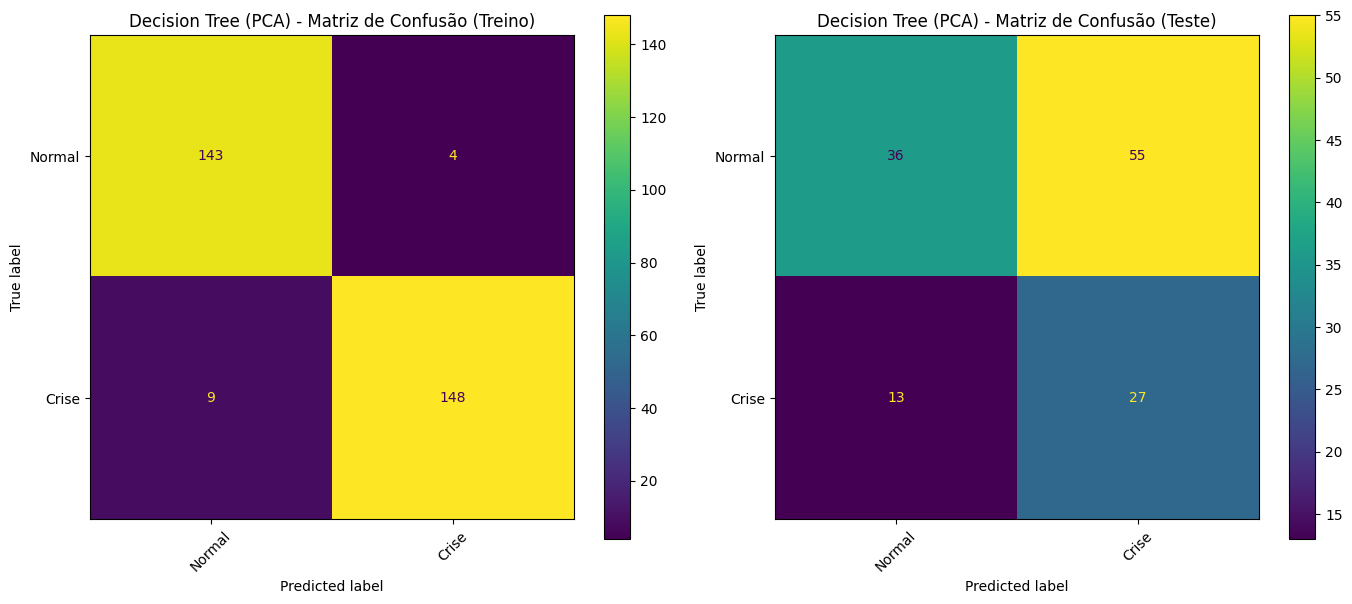

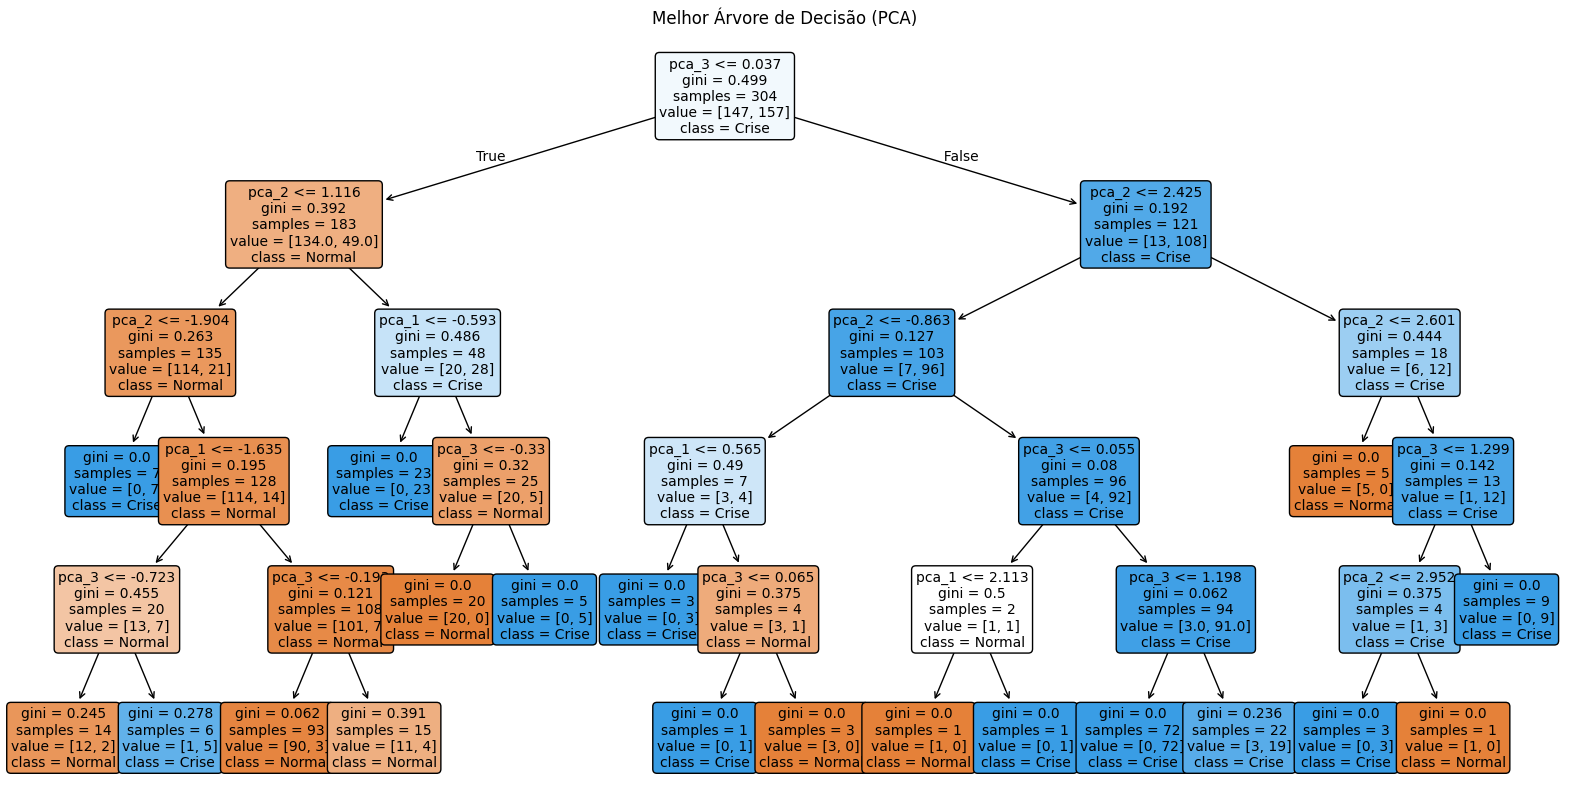

In [92]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# ===== MODELO BASE =====
tree = DecisionTreeClassifier(random_state=42)

# TREINAR SEM PCA
grid_no_pca = GridSearchCV(
    tree,
    param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1
)

inicio_treino = time.time()

grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

tempo_treino = time.time() - inicio_treino

best_tree_no_pca = grid_no_pca.best_estimator_

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_tree_no_pca.predict(X_test_no_pca)

tempo_predicao = time.time() - inicio_predicao

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_tree_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Decision Tree (sem PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_no_pca,
    feature_names=features,
    class_names=LABELS,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (sem PCA)")
plt.show()

# TREINAR COM PCA
grid_pca = GridSearchCV(
    tree,
    param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1
)

inicio_treino = time.time()

grid_pca.fit(X_train_pca, y_train_pca)

tempo_treino = time.time() - inicio_treino

best_tree_pca = grid_pca.best_estimator_

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_tree_pca.predict(X_test_pca)

tempo_predicao = time.time() - inicio_predicao

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_tree_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Decision Tree (PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_pca,
    feature_names=["pca_1", "pca_2", "pca_3"],
    class_names=LABELS,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (PCA)")
plt.show()

KNN

Melhores parâmetros (sem PCA):
{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'uniform'}

===== KNN (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       147
       Crise       0.99      0.99      0.99       157

    accuracy                           0.99       304
   macro avg       0.99      0.99      0.99       304
weighted avg       0.99      0.99      0.99       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.63      0.43      0.51        91
       Crise       0.25      0.42      0.31        40

    accuracy                           0.43       131
   macro avg       0.44      0.43      0.41       131
weighted avg       0.51      0.43      0.45       131


Tempo de treino: 0.4735 s
Tempo de predição: 20.2768 ms
Memória utilizada: 258.16 MB


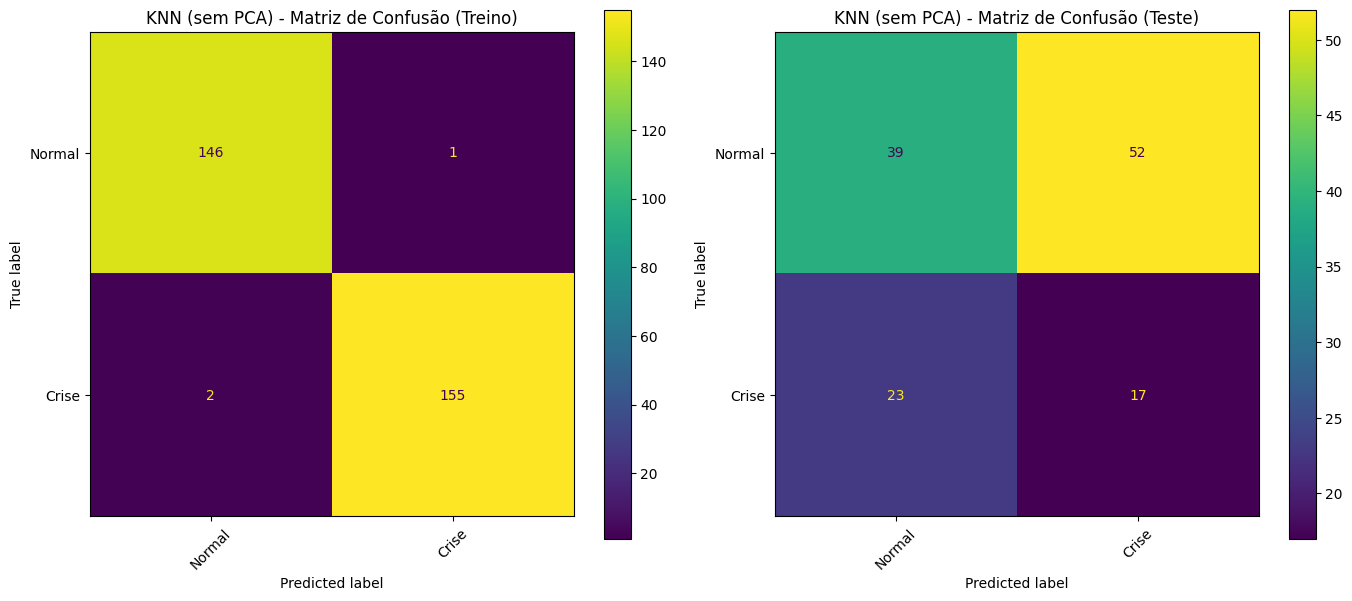

Melhores parâmetros (PCA):
{'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'uniform'}

===== KNN (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.92      0.91      0.91       147
       Crise       0.92      0.92      0.92       157

    accuracy                           0.92       304
   macro avg       0.92      0.92      0.92       304
weighted avg       0.92      0.92      0.92       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.65      0.43      0.52        91
       Crise       0.27      0.47      0.34        40

    accuracy                           0.44       131
   macro avg       0.46      0.45      0.43       131
weighted avg       0.53      0.44      0.46       131


Tempo de treino: 0.6932 s
Tempo de predição: 5.4212 ms
Memória utilizada: 262.48 MB


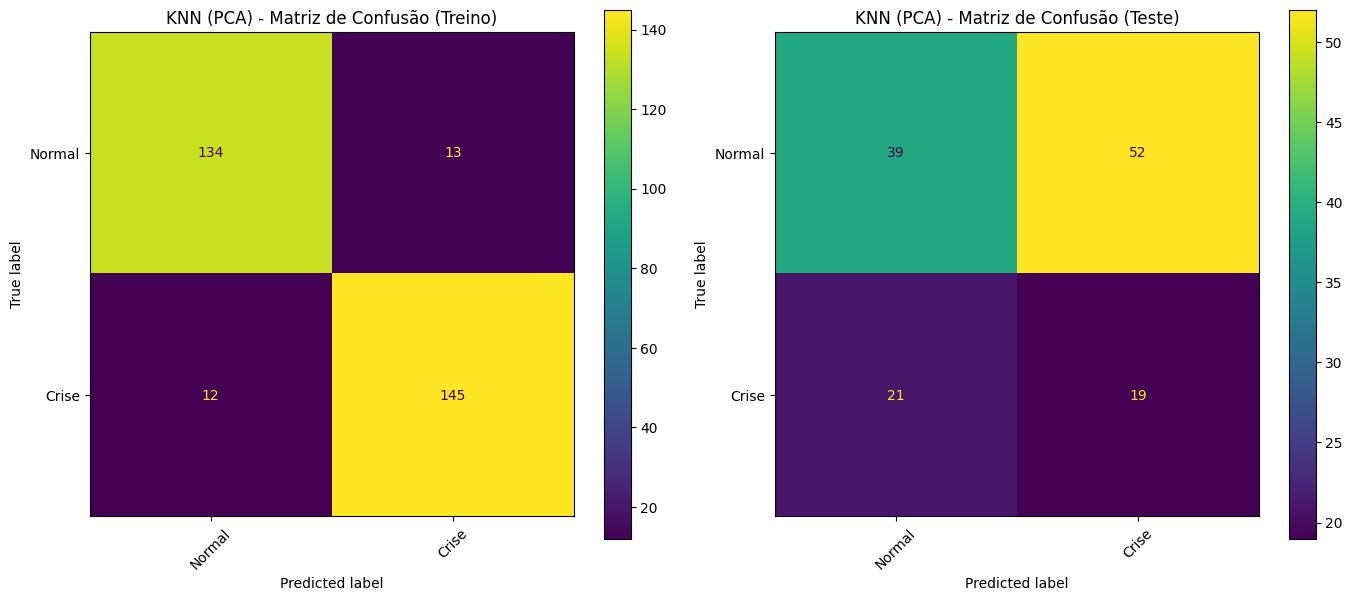

In [93]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ===== PIPELINE =====
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

# ===== GRID =====
param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

# =====================================================
# TREINAR SEM PCA
# =====================================================

grid_no_pca = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1
)

inicio_treino = time.time()

grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

tempo_treino = time.time() - inicio_treino

best_knn_no_pca = grid_no_pca.best_estimator_

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_knn_no_pca.predict(X_test_no_pca)

tempo_predicao = time.time() - inicio_predicao

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_knn_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="KNN (sem PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

# =====================================================
# TREINAR COM PCA
# =====================================================

grid_pca = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1
)

inicio_treino = time.time()

grid_pca.fit(X_train_pca, y_train_pca)

tempo_treino = time.time() - inicio_treino

best_knn_pca = grid_pca.best_estimator_

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_knn_pca.predict(X_test_pca)

tempo_predicao = time.time() - inicio_predicao

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_knn_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="KNN (PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

Voting Classifier


===== Voting Ensemble (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       147
       Crise       1.00      0.99      0.99       157

    accuracy                           0.99       304
   macro avg       0.99      0.99      0.99       304
weighted avg       0.99      0.99      0.99       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.66      0.59      0.62        91
       Crise       0.24      0.30      0.27        40

    accuracy                           0.50       131
   macro avg       0.45      0.45      0.45       131
weighted avg       0.53      0.50      0.52       131


Tempo de treino: 0.9019 s
Tempo de predição: 38.7728 ms
Memória utilizada: 265.64 MB


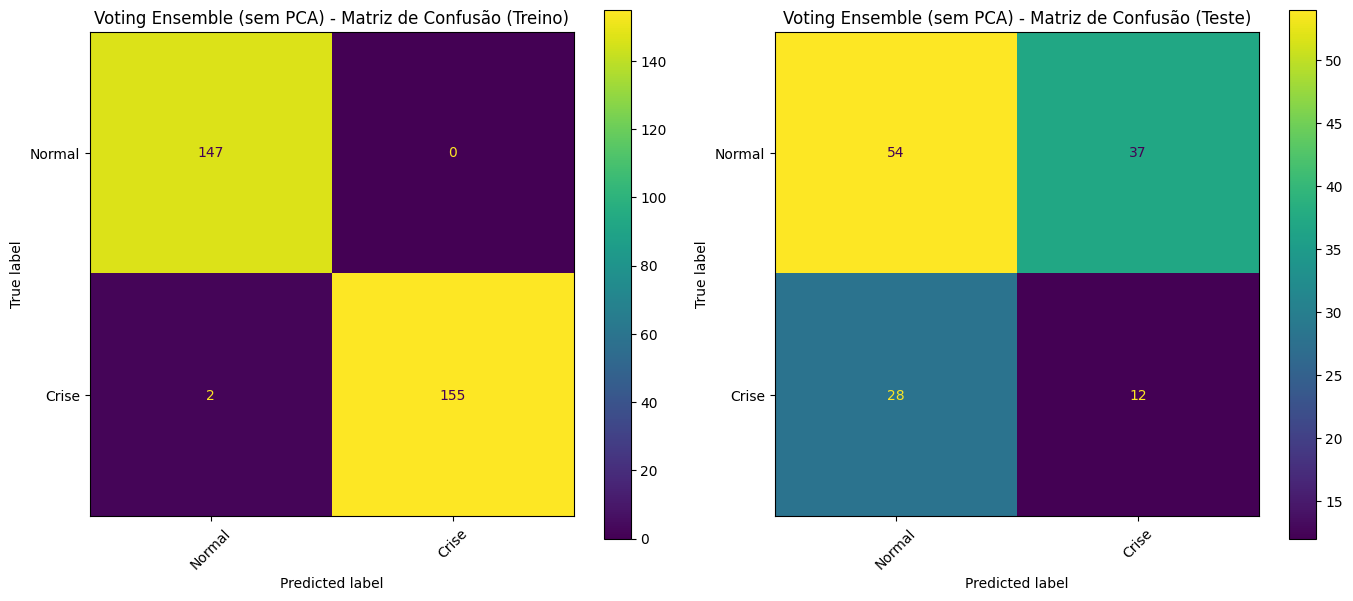


===== Voting Ensemble (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       147
       Crise       0.97      0.97      0.97       157

    accuracy                           0.97       304
   macro avg       0.97      0.97      0.97       304
weighted avg       0.97      0.97      0.97       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.67      0.35      0.46        91
       Crise       0.29      0.60      0.39        40

    accuracy                           0.43       131
   macro avg       0.48      0.48      0.43       131
weighted avg       0.55      0.43      0.44       131


Tempo de treino: 0.4216 s
Tempo de predição: 23.9465 ms
Memória utilizada: 269.91 MB


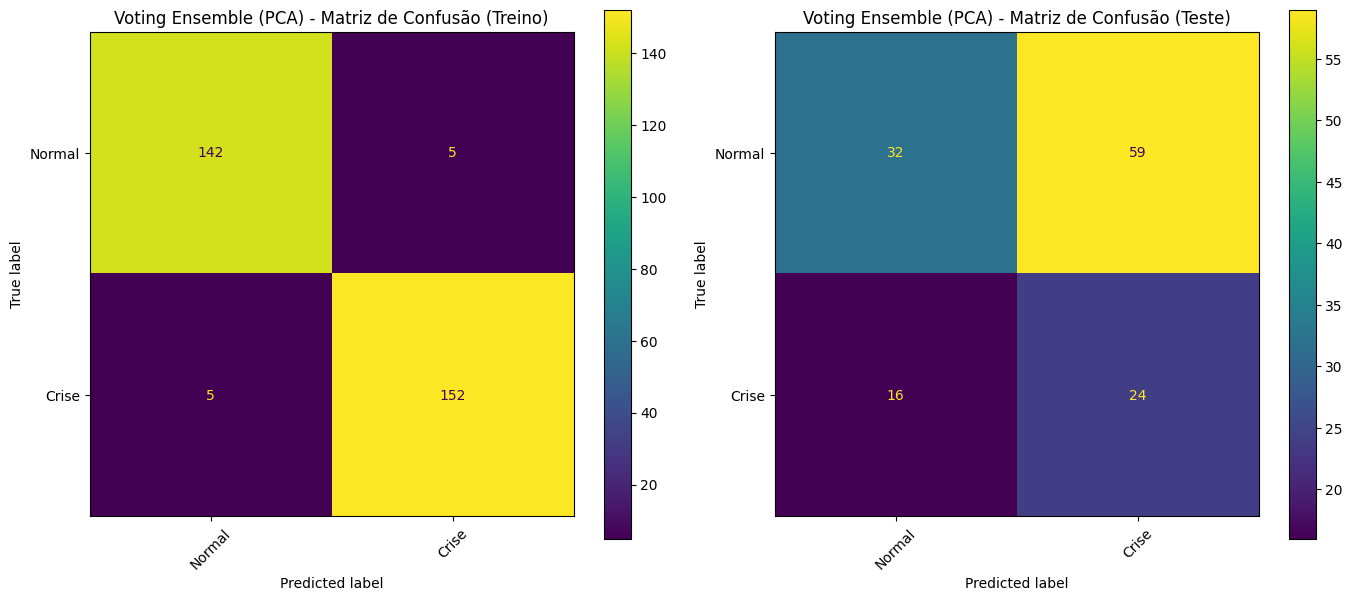

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ===== MODELOS BASE =====
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

# =====================================================
# VOTING SEM PCA
# =====================================================

voting_no_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)

inicio_treino = time.time()

voting_no_pca.fit(X_train_no_pca, y_train_no_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

voting_no_pca.predict(X_test_no_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    voting_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Voting Ensemble (sem PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

# =====================================================
# VOTING COM PCA
# =====================================================

voting_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)

inicio_treino = time.time()

voting_pca.fit(X_train_pca, y_train_pca)

tempo_treino = time.time() - inicio_treino

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

voting_pca.predict(X_test_pca)

tempo_predicao = time.time() - inicio_predicao

avaliar_modelo(
    voting_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Voting Ensemble (PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

Random Forest

Melhores parâmetros (sem PCA):
{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

===== Random Forest (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       147
       Crise       1.00      1.00      1.00       157

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.72      0.54      0.62        91
       Crise       0.33      0.53      0.41        40

    accuracy                           0.53       131
   macro avg       0.53      0.53      0.51       131
weighted avg       0.60      0.53      0.55       131


Tempo de treino: 58.0603 s
Tempo de predição: 51.1181 ms
Memória utilizada: 272.81 MB


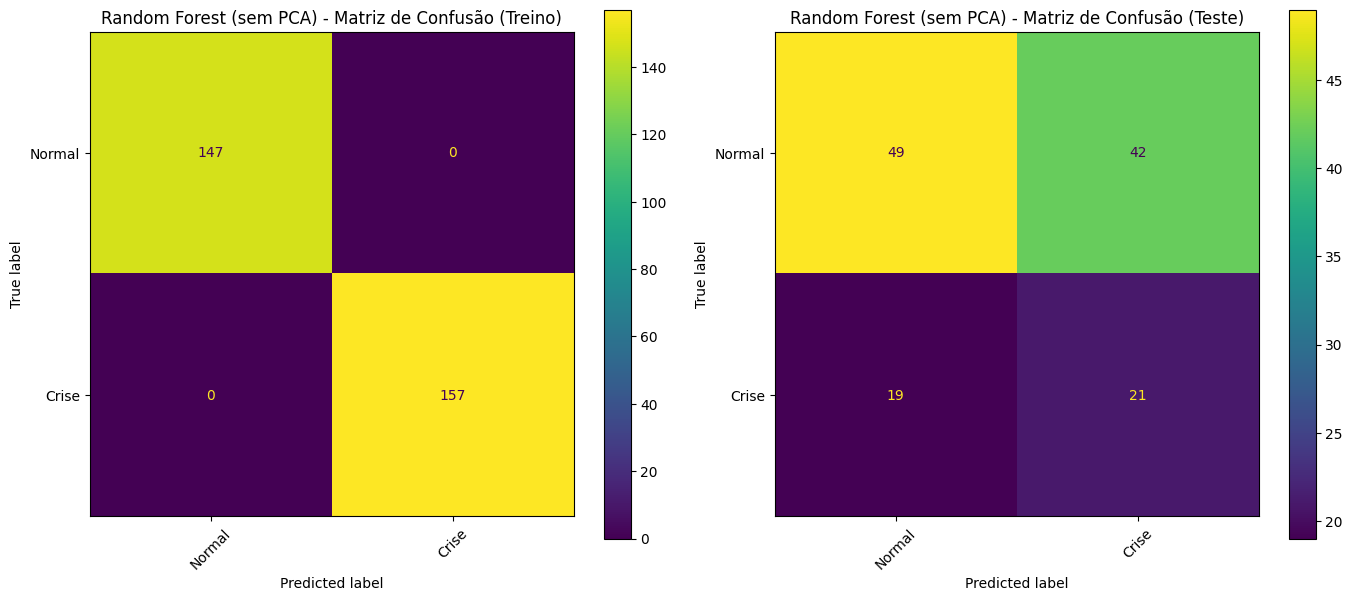


Importância das variáveis (sem PCA):
                 feature  importance
4       volatility_index    0.379397
2            price_index    0.220561
1  industrial_production    0.129273
5      yield_curve_slope    0.102862
3          real_interest    0.092801
0          credit_spread    0.075106


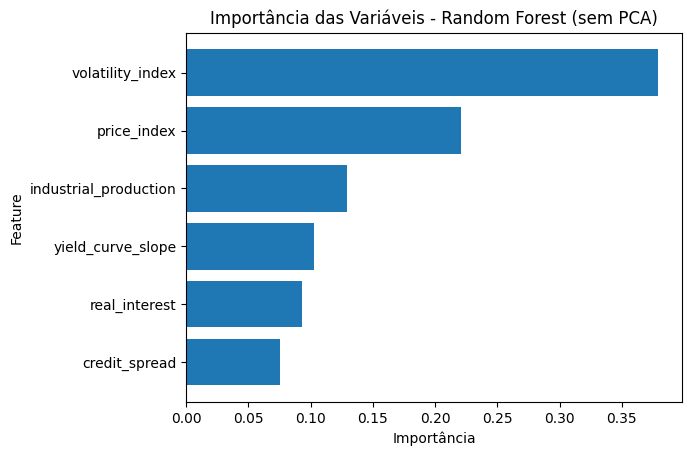

Melhores parâmetros (PCA):
{'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

===== Random Forest (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.96      0.93      0.94       147
       Crise       0.94      0.96      0.95       157

    accuracy                           0.95       304
   macro avg       0.95      0.95      0.95       304
weighted avg       0.95      0.95      0.95       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.70      0.36      0.48        91
       Crise       0.31      0.65      0.42        40

    accuracy                           0.45       131
   macro avg       0.51      0.51      0.45       131
weighted avg       0.58      0.45      0.46       131


Tempo de treino: 50.1418 s
Tempo de predição: 14.3478 ms
Memória utilizada: 277.85 MB


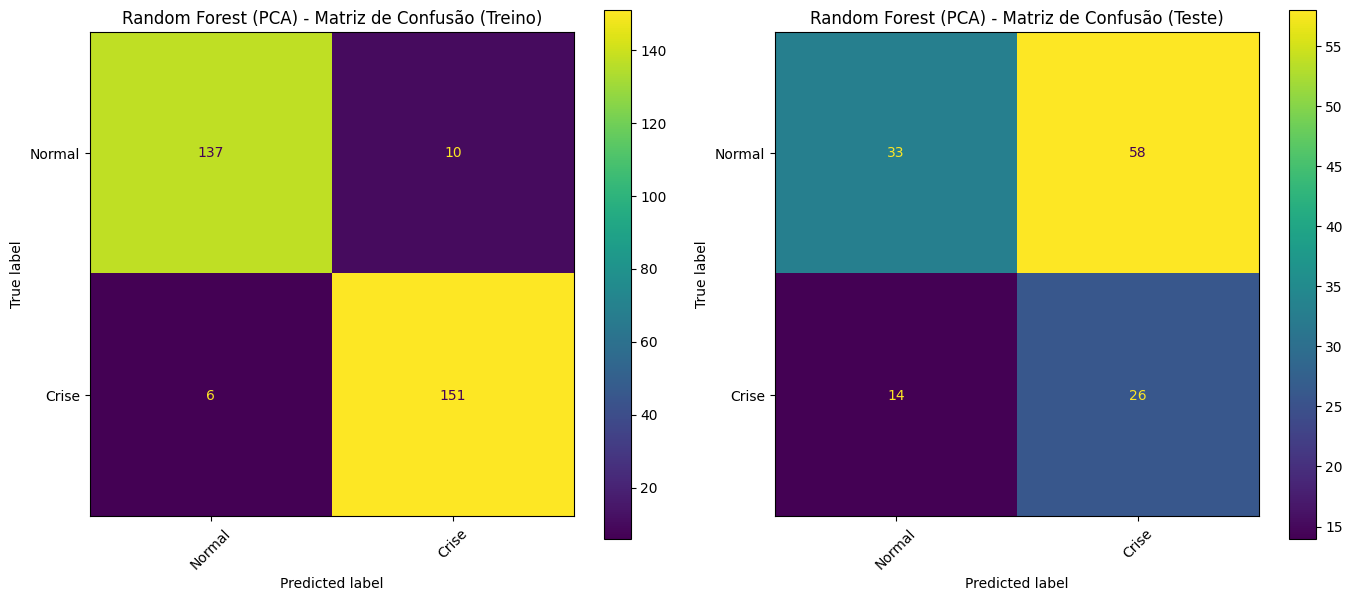


Importância das componentes PCA:
  feature  importance
2   pca_3    0.523559
0   pca_1    0.240954
1   pca_2    0.235487


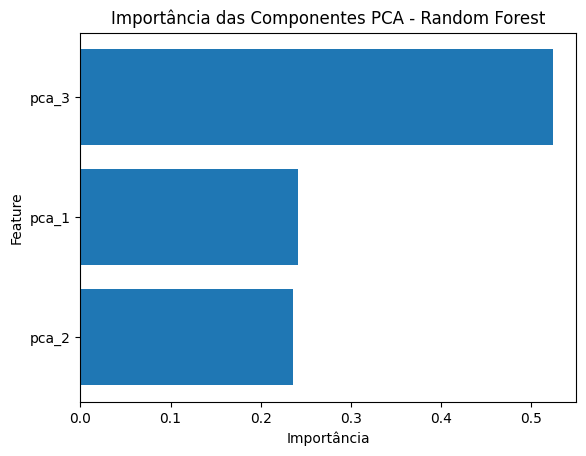

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import time
import psutil
import os

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

# ===== MODELO BASE =====
rf = RandomForestClassifier(random_state=42)

# =====================================================
# TREINAR SEM PCA
# =====================================================

grid_no_pca = GridSearchCV(
    rf,
    param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1
)

inicio_treino = time.time()

grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

tempo_treino = time.time() - inicio_treino

best_rf_no_pca = grid_no_pca.best_estimator_

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_rf_no_pca.predict(X_test_no_pca)

tempo_predicao = time.time() - inicio_predicao

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_rf_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Random Forest (sem PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

importances = best_rf_no_pca.feature_importances_

df_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nImportância das variáveis (sem PCA):")
print(df_importance)

plt.figure()
plt.barh(df_importance["feature"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis - Random Forest (sem PCA)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

# =====================================================
# TREINAR COM PCA
# =====================================================

grid_pca = GridSearchCV(
    rf,
    param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1
)

inicio_treino = time.time()

grid_pca.fit(X_train_pca, y_train_pca)

tempo_treino = time.time() - inicio_treino

best_rf_pca = grid_pca.best_estimator_

processo = psutil.Process(os.getpid())
memoria_mb = processo.memory_info().rss / 1024 / 1024

inicio_predicao = time.time()

best_rf_pca.predict(X_test_pca)

tempo_predicao = time.time() - inicio_predicao

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_rf_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Random Forest (PCA)",
    tempo_treino=tempo_treino,
    tempo_predicao=tempo_predicao,
    memoria_mb=memoria_mb
)

importances_pca = best_rf_pca.feature_importances_

df_importance_pca = pd.DataFrame({
    "feature": ["pca_1", "pca_2", "pca_3"],
    "importance": importances_pca
}).sort_values(by="importance", ascending=False)

print("\nImportância das componentes PCA:")
print(df_importance_pca)

plt.figure()
plt.barh(df_importance_pca["feature"], df_importance_pca["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Componentes PCA - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

Comparação Final

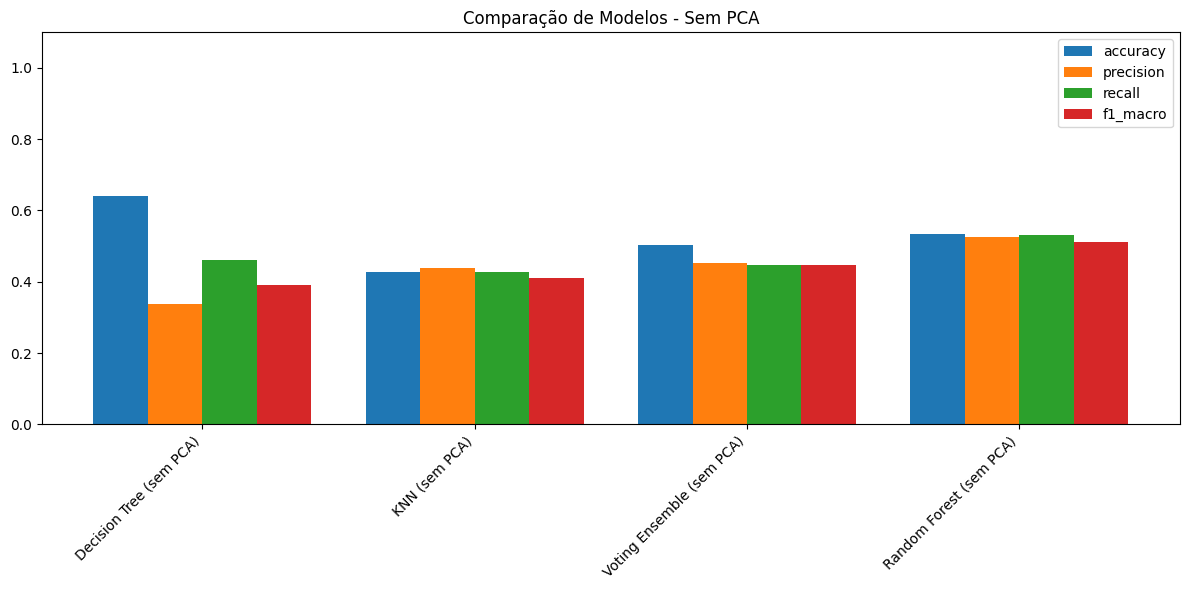

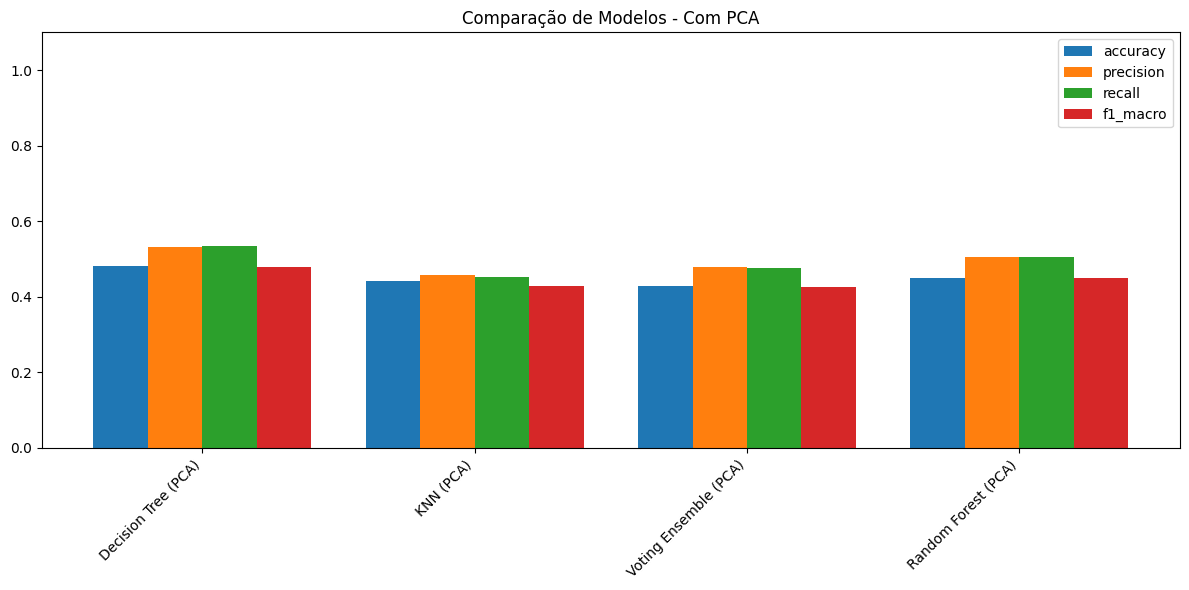

In [96]:
import numpy as np
import matplotlib.pyplot as plt

df_resultados = pd.DataFrame(resultados).set_index("modelo")

metricas = ["accuracy", "precision", "recall", "f1_macro"]
width = 0.2

# SEM PCA
modelos_sem_pca = [m for m in df_resultados.index if "sem PCA" in m]
df_sem_pca = df_resultados.loc[modelos_sem_pca]
x = np.arange(len(df_sem_pca))

fig, ax = plt.subplots(figsize=(12, 6))
for i, metrica in enumerate(metricas):
    ax.bar(x + i * width, df_sem_pca[metrica], width, label=metrica)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_sem_pca.index, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Comparação de Modelos - Sem PCA")
ax.legend()
plt.tight_layout()
plt.show()

# COM PCA
modelos_com_pca = [m for m in df_resultados.index if "sem PCA" not in m]
df_com_pca = df_resultados.loc[modelos_com_pca]
x = np.arange(len(df_com_pca))

fig, ax = plt.subplots(figsize=(12, 6))
for i, metrica in enumerate(metricas):
    ax.bar(x + i * width, df_com_pca[metrica], width, label=metrica)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_com_pca.index, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Comparação de Modelos - Com PCA")
ax.legend()
plt.tight_layout()
plt.show()

In [97]:
import pandas as pd

df_resultados = pd.DataFrame(resultados)

# Organiza colunas
df_resultados = df_resultados[
    [
        "modelo",
        "accuracy",
        "precision",
        "recall",
        "f1_macro",
        "tempo_treino_s"
    ]
]

df_resultados = df_resultados.round({
    "accuracy": 4,
    "precision": 4,
    "recall": 4,
    "f1_macro": 4,
    "tempo_treino_s": 4
})

print("\n===== RESULTADOS FINAIS =====")
print(df_resultados)


===== RESULTADOS FINAIS =====
                      modelo  accuracy  precision  recall  f1_macro  \
0    Decision Tree (sem PCA)    0.6412     0.3387  0.4615    0.3907   
1        Decision Tree (PCA)    0.4809     0.5320  0.5353    0.4785   
2              KNN (sem PCA)    0.4275     0.4377  0.4268    0.4109   
3                  KNN (PCA)    0.4427     0.4588  0.4518    0.4294   
4  Voting Ensemble (sem PCA)    0.5038     0.4517  0.4467    0.4470   
5      Voting Ensemble (PCA)    0.4275     0.4779  0.4758    0.4253   
6    Random Forest (sem PCA)    0.5344     0.5270  0.5317    0.5121   
7        Random Forest (PCA)    0.4504     0.5058  0.5063    0.4488   

   tempo_treino_s  
0          0.4982  
1          0.5205  
2          0.4735  
3          0.6932  
4          0.9019  
5          0.4216  
6         58.0603  
7         50.1418  
